ASSIGNMENT **1**


In [35]:
# QUESTION 1.1
import numpy as np

arr = np.linspace(0,20,100)
arr_mean = np.mean(arr)
arr_median = np.median(arr)
arr_std = np.std(arr)
arr_var = np.var(arr)

print(f"Mean: {arr_mean}")
print(f"Median: {arr_median}")
print(f"Std: {arr_std}")
print(f"Var: {arr_var}")

Mean: 10.0
Median: 10.0
Std: 5.831529302570125
Var: 34.00673400673401


In [36]:
# QUESTION 1.2
import numpy as np

array_1 = range(1,37,1)
arr = np.array(array_1)
print(arr.shape)
arr_reshaped = arr.reshape(4,9)
print(arr_reshaped.shape)
arr_flattened = arr.reshape(-1)
print(arr_flattened.shape)



(36,)
(4, 9)
(36,)


In [37]:
# QUESTION 2.1
import seaborn as sns
df = sns.load_dataset('titanic')
print(df.head())
print(df.info())
print(df.describe())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-nu

In [38]:
# QUESTION 2.2
import pandas as pd
import seaborn as sns
df = sns.load_dataset('titanic')

missing_count = df.isnull().sum()
missing_count = missing_count[missing_count > 0]
missing_percentage = (missing_count / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_percentage
})
print(missing_info)

df['age'] = df['age'].fillna(df.groupby('pclass')['age'].transform('median'))

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

df.drop(columns=['deck'], inplace=True)

print(df[['age', 'embarked']].isnull().sum())



             Missing Count  Percentage (%)
age                    177       19.865320
embarked                 2        0.224467
deck                   688       77.216611
embark_town              2        0.224467
age         0
embarked    0
dtype: int64


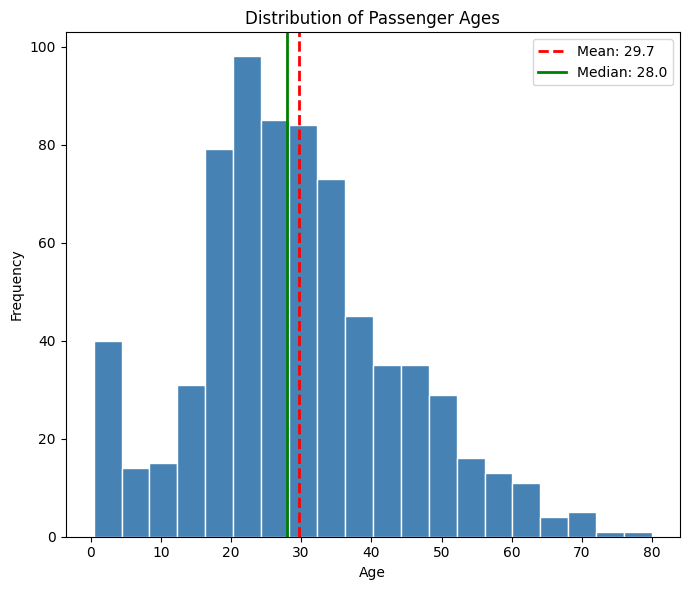

In [39]:
#   QUESTION 3.1
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

df = df.dropna(subset=['age'])

mean_age = df['age'].mean()
median_age = df['age'].median()

plt.figure(figsize=(7, 6))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f}')
plt.axvline(median_age, color='green', linestyle='-', linewidth=2, label=f'Median: {median_age:.1f}')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()



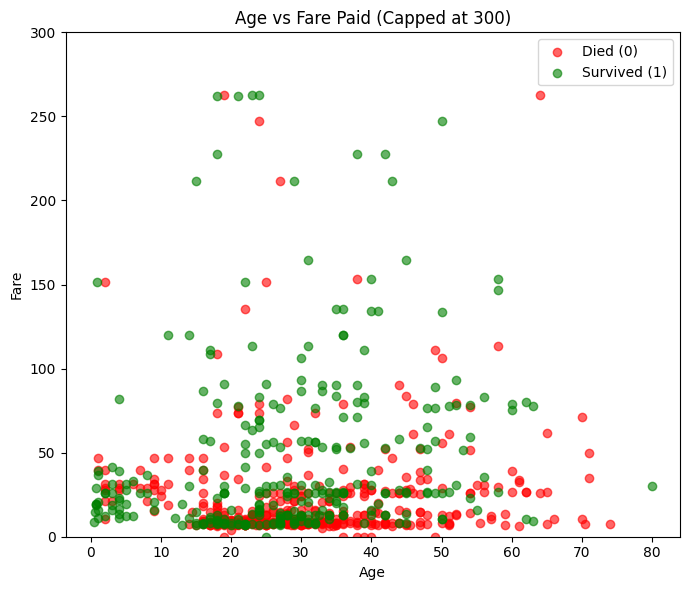

In [40]:
# QUESTION 3.2
import matplotlib.pyplot as plt
import pandas as pd

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)


df = df.dropna(subset=['age', 'fare', 'survived'])

survived = df[df['survived'] == 1]
not_survived = df[df['survived'] == 0]

plt.figure(figsize=(7, 6))
plt.scatter(not_survived['age'], not_survived['fare'], color='red', alpha=0.6, label='Died (0)')
plt.scatter(survived['age'], survived['fare'], color='green', alpha=0.6, label='Survived (1)')
plt.ylim(0, 300)
plt.title('Age vs Fare Paid (Capped at 300)')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.tight_layout()
plt.show()


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


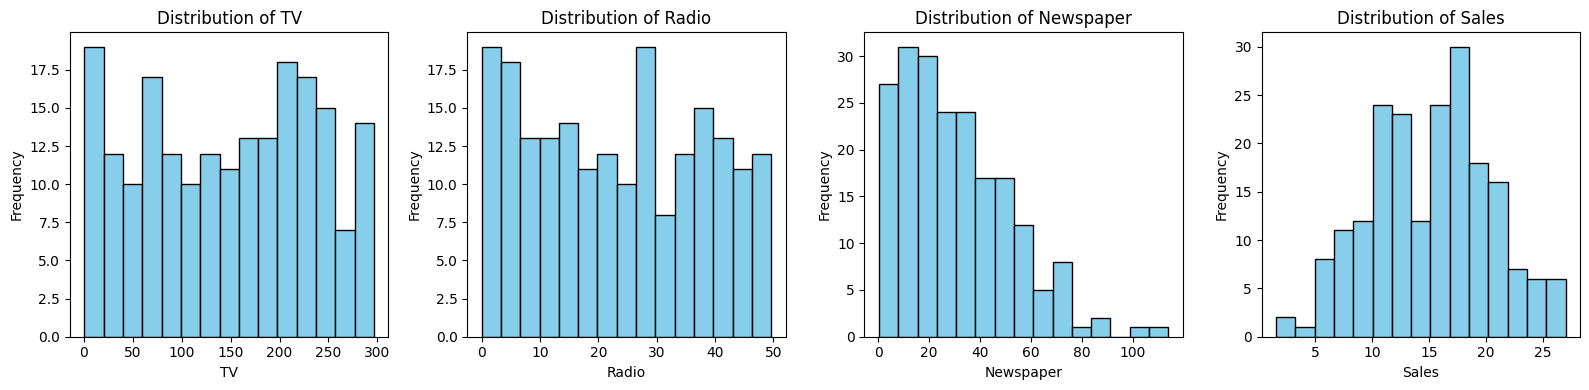

In [24]:
# QUESTION 4.1
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/advertising.csv")
print(df.shape)
print(df.info())
print(df.isnull().sum())

print(df.describe())

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
columns_set = df.columns
for i, col in enumerate(columns_set):
  axes[i].hist(df[col], bins=15, color='skyblue', edgecolor='black')
  axes[i].set_title(f'Distribution of {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

                 TV     Radio  Newspaper     Sales
TV         1.000000  0.054809   0.056648  0.901208
Radio      0.054809  1.000000   0.354104  0.349631
Newspaper  0.056648  0.354104   1.000000  0.157960
Sales      0.901208  0.349631   0.157960  1.000000


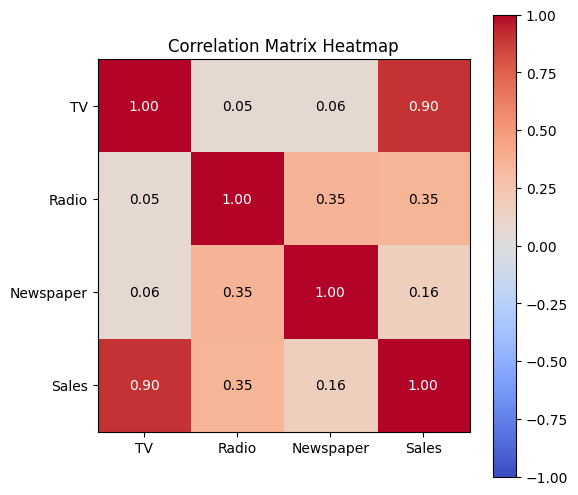

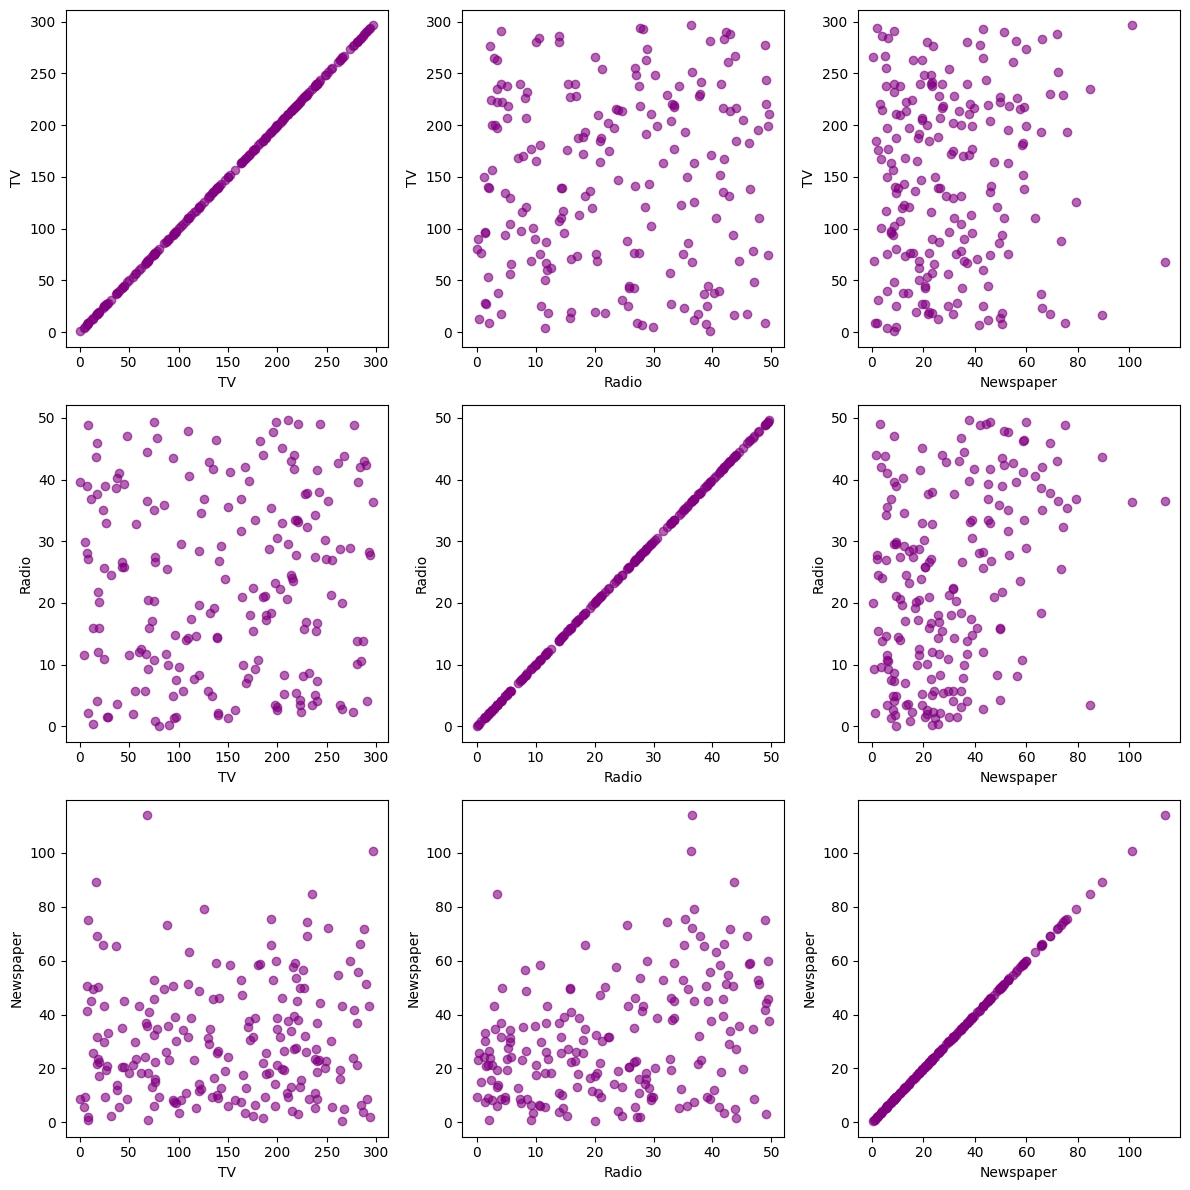

In [25]:
# QUESTION 4.2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/advertising.csv')

corr_matrix = df.corr()
print(corr_matrix)

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ticks = np.arange(len(df.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(df.columns)
ax.set_yticklabels(df.columns)

for i in range(len(df.columns)):
    for j in range(len(df.columns)):
        value = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="black" if abs(value) < 0.7 else "white")

plt.title("Correlation Matrix Heatmap")
plt.show()

features = ['TV', 'Radio', 'Newspaper']
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):
        x_feature = features[j]
        y_feature = features[i]
        axes[i, j].scatter(df[x_feature], df[y_feature], alpha=0.6, color='purple')
        axes[i, j].set_xlabel(x_feature)
        axes[i, j].set_ylabel(y_feature)

plt.tight_layout()
plt.show()

Clearly, TV is most correlated feature with Sales.

No, TV and Radio are not correlated as their correlation value is almost close to 0.

In [26]:
# QUESTION 5.1
import pandas as pd
import numpy as np
df = pd.read_csv("/content/drive/MyDrive/advertising.csv")
print(df)
df_train = df.iloc[:160]
df_test = df.iloc[160:]

y = df_train['Sales']

def linear_regression(x,y):
  x_mean = np.mean(x)
  y_mean = np.mean(y)

  m = np.sum((x-x_mean)*(y-y_mean))/np.sum((x-x_mean)**2)
  b = y_mean - m*x_mean
  return m,b

def mean_squared_error(m,b,x,y):
    y_pred = m*x + b

    error = np.mean((y_pred-y)**2)
    return error

features = ['Newspaper', 'TV', 'Radio']

results = [
linear_regression(df_train[features[0]],y),
linear_regression(df_train[features[1]],y),
linear_regression(df_train[features[2]],y)
]
i=0

for m,b in results:
    print(f"The values are m = {m} and b = {b}")
    error = mean_squared_error(m,b,df_test[features[i]],df_test['Sales'])
    print(f"MSE is {error}")
    i+=1






        TV  Radio  Newspaper  Sales
0    230.1   37.8       69.2   22.1
1     44.5   39.3       45.1   10.4
2     17.2   45.9       69.3   12.0
3    151.5   41.3       58.5   16.5
4    180.8   10.8       58.4   17.9
..     ...    ...        ...    ...
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

[200 rows x 4 columns]
The values are m = 0.034786398782922195 and b = 13.842399973101667
MSE is 26.77648521974112
The values are m = 0.05572601895005874 and b = 6.993686960994353
MSE is 5.459799471482253
The values are m = 0.1239916364053927 and b = 11.934139103071898
MSE is 24.30776581502904


In [27]:
# QUESTION 5.2
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.read_csv("/content/drive/MyDrive/advertising.csv")
X = df[['TV']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient(m):",model.coef_[0])
print("Intercept(b):",model.intercept_)


Coefficient(m): 0.0554829439314632
Intercept(b): 7.007108428241848


The values from Q5.1 and Q5.2 are close enough.
The difference is because train split uses random 80% of data to train the model whereas in manual case the first 80% was used.

This causes a slight difference in their mean values and hence the slope and intercept


In [28]:
# QUESTION 5.3
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
df = pd.read_csv("/content/drive/MyDrive/advertising.csv")
X = df[['TV']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

m = model.coef_[0]
b = model.intercept_

def mean_absolute_error(m,b,x,y):
    y_pred = m*x + b
    error = np.mean(np.abs(y_pred-y))
    return error

def mean_squared_error(m,b,x,y):
    y_pred = m*x + b
    error = np.mean((y_pred-y)**2)
    return error

def root_mean_squared_error(m,b,x,y):
    error = np.sqrt(mean_squared_error(m,b,x,y))
    return error

def  r2_score(m,b,x,y):
     y_pred = m*x + b
     error = 1-(np.sum((y-y_pred)**2))/(np.sum((y-np.mean(y))**2))
     return error

X_train_arr = np.array(X_train).flatten()
X_test_arr = np.array(X_test).flatten()
y_train_arr = np.array(y_train)
y_test_arr = np.array(y_test)

print("Train Set")
print(f"MAE: {mean_absolute_error(m, b, X_train_arr, y_train_arr)}")
print(f"MSE: {mean_squared_error(m, b, X_train_arr, y_train_arr)}")
print(f"RMSE: {root_mean_squared_error(m, b, X_train_arr, y_train_arr)}")
print(f"R2 Score: {r2_score(m, b, X_train_arr, y_train_arr)}")

print("Test Set")
print(f"MAE: {mean_absolute_error(m, b, X_test_arr, y_test_arr)}")
print(f"MSE: {mean_squared_error(m, b, X_test_arr, y_test_arr)}")
print(f"RMSE: {root_mean_squared_error(m, b, X_test_arr, y_test_arr)}")
print(f"R2 Score: {r2_score(m, b, X_test_arr, y_test_arr)}")


Train Set
MAE: 1.8005092256620792
MSE: 4.998442356450173
RMSE: 2.235719650683013
R2 Score: 0.8134866044709264
Test Set
MAE: 1.9502948931650088
MSE: 6.101072906773963
RMSE: 2.470035001123256
R2 Score: 0.802561303423698


Clearly there is no much significant difference in errors of the train data set and test data set.

The model is well fit.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


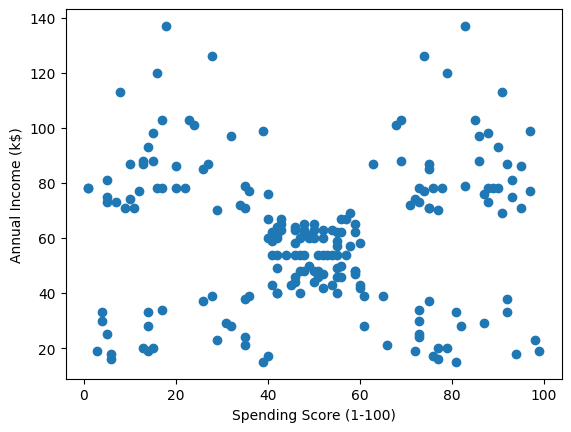

In [29]:
# QUESTION 6.1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")
df.info()
df.head()
df.describe()

y = df["Annual Income (k$)"]
x = df["Spending Score (1-100)"]

plt.scatter(x,y)

plt.xlabel("Spending Score (1-100)")
plt.ylabel("Annual Income (k$)")

plt.show()



According to the plot, I would guess that there are 5 natural groupings.

In [30]:
# QUESTION 6.2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("/content/drive/MyDrive/Mall_Customers.csv")
df_req = df[["Annual Income (k$)","Spending Score (1-100)"]]

kmeans = KMeans(n_clusters=5, init = 'k-means++', random_state=42)
df['Cluster'] = kmeans.fit_predict(df_req)

centroids = kmeans.cluster_centers_
centroids_df = pd.DataFrame(
    centroids,
    columns=["Centroid Annual Income" , "Centroid Spending Score"]
)
centroids_df.index.name = "Cluster ID"
print(centroids_df.round(2).to_string())

cluster_summary = df.groupby('Cluster').agg(
    Customer_Count = ('CustomerID','count'),
    Mean_Annual_Income = ('Annual Income (k$)','mean'),
    Mean_Spending_Score = ('Spending Score (1-100)', 'mean')
)

print("SUMMARY")
for cluster_id, row in cluster_summary.iterrows():
    print(f"Cluster {cluster_id}:")
    print(f"Count of customers: {int(row['Customer_Count'])}")
    print(f"Mean Annual Income: ${row['Mean_Annual_Income']:.2f}k")
    print(f"Mean Spending Score: {row['Mean_Spending_Score']:.2f}")


            Centroid Annual Income  Centroid Spending Score
Cluster ID                                                 
0                            55.30                    49.52
1                            86.54                    82.13
2                            25.73                    79.36
3                            88.20                    17.11
4                            26.30                    20.91
SUMMARY
Cluster 0:
Count of customers: 81
Mean Annual Income: $55.30k
Mean Spending Score: 49.52
Cluster 1:
Count of customers: 39
Mean Annual Income: $86.54k
Mean Spending Score: 82.13
Cluster 2:
Count of customers: 22
Mean Annual Income: $25.73k
Mean Spending Score: 79.36
Cluster 3:
Count of customers: 35
Mean Annual Income: $88.20k
Mean Spending Score: 17.11
Cluster 4:
Count of customers: 23
Mean Annual Income: $26.30k
Mean Spending Score: 20.91


X_train shape: (60000, 28, 28), y_train shape: (60000,)
X_test shape: (10000, 28, 28), y_test shape: (10000,)


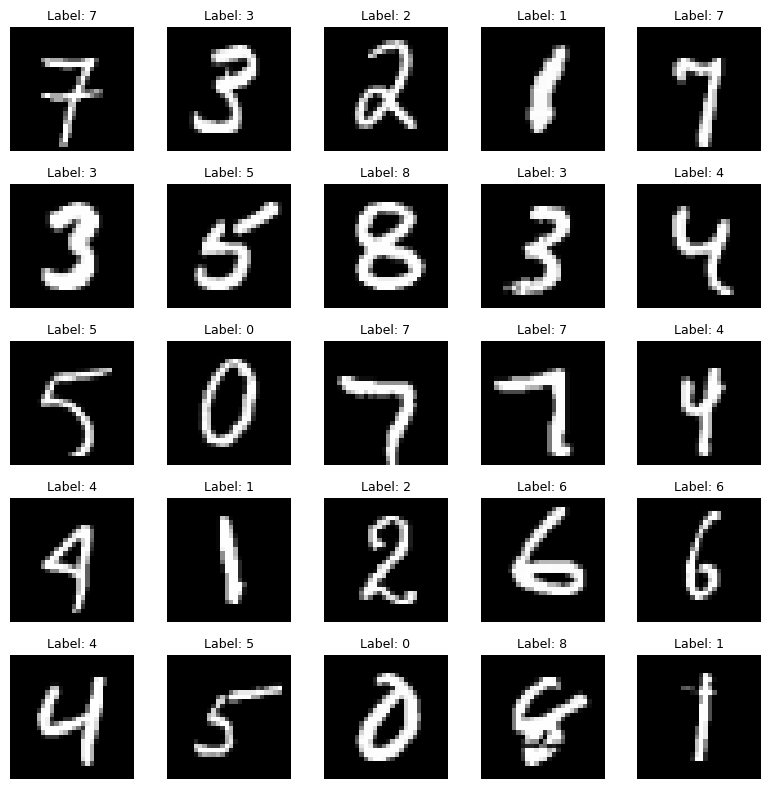

In [31]:
# QUESTION 7.1
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist

# Load the dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

# Normalize pixel values to [0, 1]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

# Display a 5x5 grid of random images
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
indices = np.random.choice(len(X_train_norm), 25, replace=False)
for i, ax in enumerate(axes.flat):
    idx = indices[i]
    ax.imshow(X_train_norm[idx], cmap='gray')
    ax.set_title(f"Label: {y_train[idx]}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9160 - loss: 0.2986 - val_accuracy: 0.9565 - val_loss: 0.1546
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9640 - loss: 0.1230 - val_accuracy: 0.9635 - val_loss: 0.1173
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9747 - loss: 0.0849 - val_accuracy: 0.9666 - val_loss: 0.1058
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9804 - loss: 0.0629 - val_accuracy: 0.9708 - val_loss: 0.1001
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9859 - loss: 0.0471 - val_accuracy: 0.9730 - val_loss: 0.0907
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9874 - loss: 0.0400 - val_accuracy: 0.9722 - val_loss: 0.0993
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9905 - loss: 0.0299 - val_accuracy: 0.9743 - val_loss: 0.0909
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9913 - loss: 0.0274 - val_accuracy: 0.

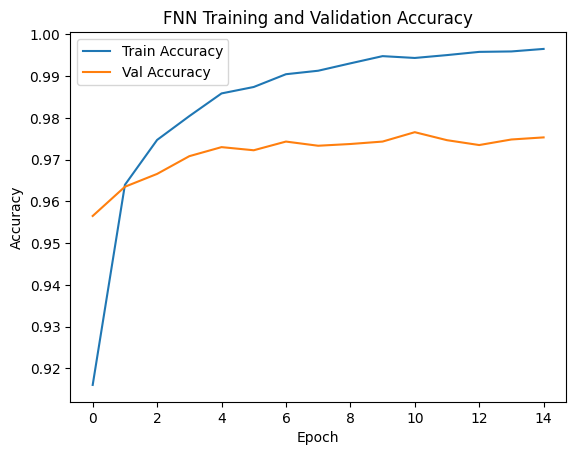

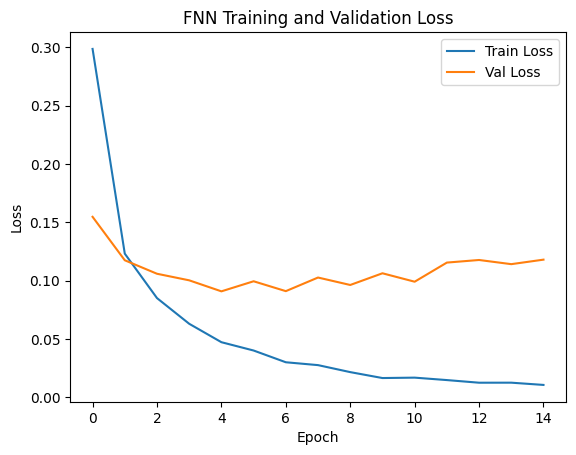

In [32]:
# QUESTION 7.2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

fnn_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

fnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

fnn_model.summary()

fnn_history = fnn_model.fit(X_train_norm, y_train, epochs=15, validation_split=0.2, batch_size=64)

plt.figure()
plt.plot(fnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(fnn_history.history['val_accuracy'], label='Val Accuracy')
plt.title('FNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(fnn_history.history['loss'], label='Train Loss')
plt.plot(fnn_history.history['val_loss'], label='Val Loss')
plt.title('FNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

FNN Test Loss: 0.1054, FNN Test Accuracy: 0.9767
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


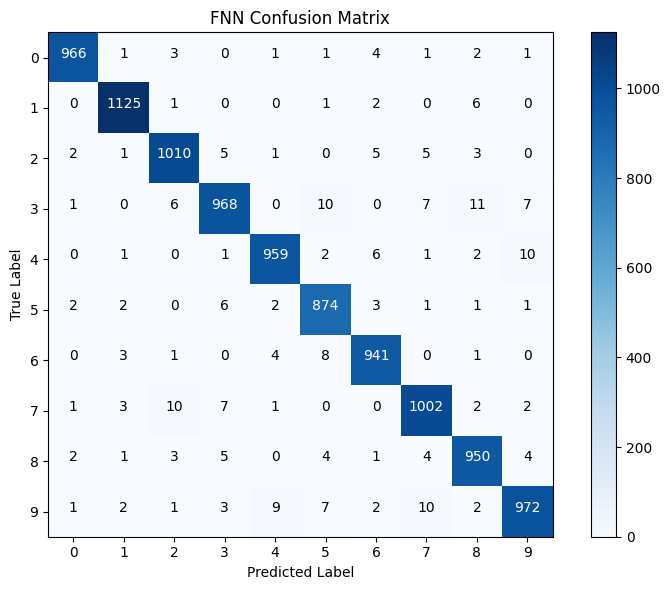

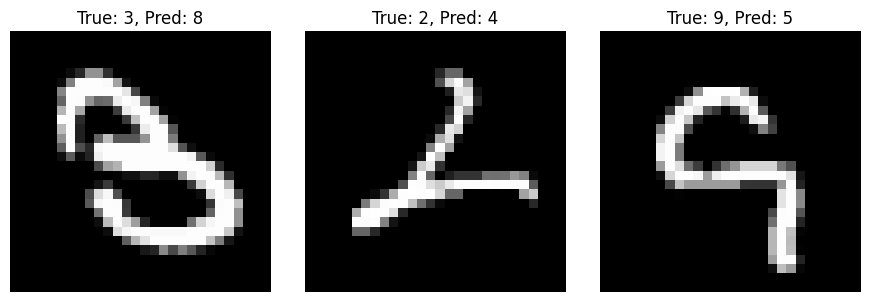

In [33]:
# QUESTION 7.3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

fnn_loss, fnn_acc = fnn_model.evaluate(X_test_norm, y_test, verbose=0)
print(f"FNN Test Loss: {fnn_loss:.4f}, FNN Test Accuracy: {fnn_acc:.4f}")

y_pred_probs = fnn_model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues', interpolation='nearest')
plt.title('FNN Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for i in range(10):
    for j in range(10):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black")
plt.tight_layout()
plt.show()

misclassified_idx = np.where(y_test != y_pred)[0]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, ax in enumerate(axes):
    idx = misclassified_idx[i]
    ax.imshow(X_test[idx], cmap='gray')
    ax.set_title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    ax.axis('off')
plt.tight_layout()
plt.show()



In [34]:
# QUESTION 7,4
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Conv2D, MaxPooling2D

X_train_cnn = X_train_norm.reshape(-1, 28, 28, 1)
X_test_cnn = X_test_norm.reshape(-1, 28, 28, 1)

cnn_model = Sequential([
    Conv2D(32, kernel_size=(3,3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

cnn_model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

cnn_model.summary()

cnn_history = cnn_model.fit(X_train_cnn, y_train, epochs=10, validation_split=0.2, batch_size=64)

cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9453 - loss: 0.1811 - val_accuracy: 0.9818 - val_loss: 0.0624
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9840 - loss: 0.0501 - val_accuracy: 0.9875 - val_loss: 0.0422
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9888 - loss: 0.0347 - val_accuracy: 0.9847 - val_loss: 0.0521
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9919 - loss: 0.0249 - val_accuracy: 0.9874 - val_loss: 0.0413
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9942 - loss: 0.0186 - val_accuracy: 0.9888 - val_loss: 0.0446
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9950 - loss: 0.0148 - val_accuracy: 0.9882 - val_loss: 0.0459
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9960 - loss: 0.0117 - val_accuracy: 0.9882 - val_loss: 0.0419
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9965 - loss: 0.0102 - val_accuracy: 0.